# 유형 A 상권 분석 — 강남·서초·송파 고소득 직장인 페르소나

**분석 목적**: A유형 상권이 지금 어떤 상태이고, 어떤 문제가 있으며, 상권 유형별로 어떤 전략을 써야 매출을 끌어올릴 수 있는가를 데이터로 제시한다.

**분석 흐름**
1. 현황 — 규모·시간대·고객 프로파일
2. 상권 세분화 — K-Means 4개 유형 도출
3. 유형별 문제 진단 + 맞춤 전략 + **예상 매출 지표**
4. 지도 시각화 (유형별 색상)

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import folium
from folium.plugins import MiniMap
from pyproj import Transformer
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

OKR_COLORS = ['#2166ac', '#d6604d', '#1a9850', '#f4a582']  # 클러스터 색상

In [96]:
# ── 1. 영역 데이터: 강남·서초·송파 상권 목록 + 좌표 변환
df_area = pd.read_csv(
    '../data/extracted/서울시_상권분석서비스(추정매출+영역)/서울시 상권분석서비스(영역-상권).csv',
    encoding='euc-kr'
)
TARGET_GU = ['강남구', '서초구', '송파구']
df_area_a = df_area[df_area['자치구_코드_명'].isin(TARGET_GU)].copy()
target_codes = set(df_area_a['상권_코드'])

# TM(EPSG:5174) → WGS84(EPSG:4326)  |  always_xy=True: input (Easting=X, Northing=Y)
transformer = Transformer.from_crs('EPSG:5174', 'EPSG:4326', always_xy=True)
lons, lats = transformer.transform(
    df_area_a['엑스좌표_값'].values,
    df_area_a['와이좌표_값'].values
)
df_area_a = df_area_a.copy()
df_area_a['lat'] = lats
df_area_a['lon'] = lons

print(f'대상 상권 수: {len(df_area_a)}개')
df_area_a[['상권_코드_명', '자치구_코드_명', 'lat', 'lon']].head(5)

대상 상권 수: 247개


,상권_코드_명,자치구_코드_명,lat,lon
831,문정역 2번,송파구,37.486780,127.126804
832,문정초등학교,송파구,37.491375,127.127275
833,경찰병원역 3번,송파구,37.496908,127.126662
839,염곡동 구룡사(포이동성당),서초구,37.472332,127.046686
840,법제교육센터(버들어린이공원),서초구,37.476224,127.047174


In [97]:
# ── 2. 추정매출 2025년 4분기(20254) + 강남·서초·송파 필터
df_sales_raw = pd.read_csv(
    '../data/extracted/서울시_상권분석서비스(추정매출+영역)/서울시_상권분석서비스(추정매출-상권)_2025년.csv',
    encoding='euc-kr'
)
df_sales_a = df_sales_raw[
    (df_sales_raw['기준_년분기_코드'] == 20254) &
    (df_sales_raw['상권_코드'].isin(target_codes))
].copy()

# ── 3. 길단위 인구 + 강남·서초·송파 필터
df_pop_raw = pd.read_csv(
    '../data/extracted/서울시 상권분석서비스(길단위인구-상권)/서울시 상권분석서비스(길단위인구-상권).csv',
    encoding='euc-kr'
)
df_pop_a = df_pop_raw[df_pop_raw['상권_코드'].isin(target_codes)].copy()

print(f'추정매출: {len(df_sales_a)}행 (업종별) / {df_sales_a["상권_코드"].nunique()}개 상권')
print(f'길단위인구: {len(df_pop_a)}행 / 분기: {df_pop_a["기준_년분기_코드"].unique()}')
print(f'업종 종류: {df_sales_a["서비스_업종_코드_명"].nunique()}개')
df_sales_a[['상권_코드_명', '서비스_업종_코드_명', '당월_매출_금액', '당월_매출_건수']].head(5)

추정매출: 4016행 (업종별) / 233개 상권
길단위인구: 6900행 / 분기: [20254 20253 20252 20251 20244 20243 20242 20241 20234 20233 20232 20231
 20224 20223 20222 20221 20214 20213 20212 20211 20204 20203 20202 20201
 20194 20193 20192 20191]
업종 종류: 62개


,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수
0,강남 마이스 관광특구,조명용품,185366106,484
1,강남 마이스 관광특구,가전제품,48955198,130
2,강남 마이스 관광특구,가구,4175008925,3031
3,강남 마이스 관광특구,화초,755551967,6197
4,강남 마이스 관광특구,완구,2258493446,52021


In [98]:
# ── 상권별 핵심 지표 집계 (클러스터링 피처 포함)
g = df_sales_a.groupby('상권_코드').agg(
    총매출=('당월_매출_금액', 'sum'),
    총건수=('당월_매출_건수', 'sum'),
    오전매출=('시간대_06~11_매출_금액', 'sum'),
    점심매출=('시간대_11~14_매출_금액', 'sum'),
    오후매출=('시간대_14~17_매출_금액', 'sum'),
    저녁매출=('시간대_17~21_매출_금액', 'sum'),
    야간매출=('시간대_21~24_매출_금액', 'sum'),
    주중매출=('주중_매출_금액', 'sum'),
    주말매출=('주말_매출_금액', 'sum'),
    남성매출=('남성_매출_금액', 'sum'),
    여성매출=('여성_매출_금액', 'sum'),
    연령20매출=('연령대_20_매출_금액', 'sum'),
    연령30매출=('연령대_30_매출_금액', 'sum'),
    연령40매출=('연령대_40_매출_금액', 'sum'),
    연령50매출=('연령대_50_매출_금액', 'sum'),
).reset_index()

# 비율 피처 (클러스터링에 사용)
g['점심비중'] = g['점심매출'] / g['총매출']
g['저녁비중'] = g['저녁매출'] / g['총매출']
g['야간비중'] = g['야간매출'] / g['총매출']
g['주말비중'] = g['주말매출'] / g['총매출']
g['여성비중'] = g['여성매출'] / g['총매출']
g['연령3040비중'] = (g['연령30매출'] + g['연령40매출']) / g['총매출']
g['객단가'] = g['총매출'] / g['총건수'].replace(0, np.nan)

# 상권명·좌표 합류
g = g.merge(
    df_area_a[['상권_코드', '상권_코드_명', '자치구_코드_명', 'lat', 'lon']],
    on='상권_코드', how='left'
)
g = g.dropna(subset=['총매출', '점심비중', '저녁비중', '야간비중', '주말비중', '여성비중', '객단가'])
g = g[g['총매출'] > 0].reset_index(drop=True)

# 총매출 단위: 억원
g['총매출_억'] = g['총매출'] / 1e8

print(f'분석 상권: {len(g)}개')
print(f'월 평균 매출: {g["총매출_억"].mean():.1f}억원  (중앙값 {g["총매출_억"].median():.1f}억원)')
print(f'객단가 중앙값: {g["객단가"].median():,.0f}원')

분석 상권: 233개
월 평균 매출: 283.9억원  (중앙값 56.7억원)
객단가 중앙값: 34,374원


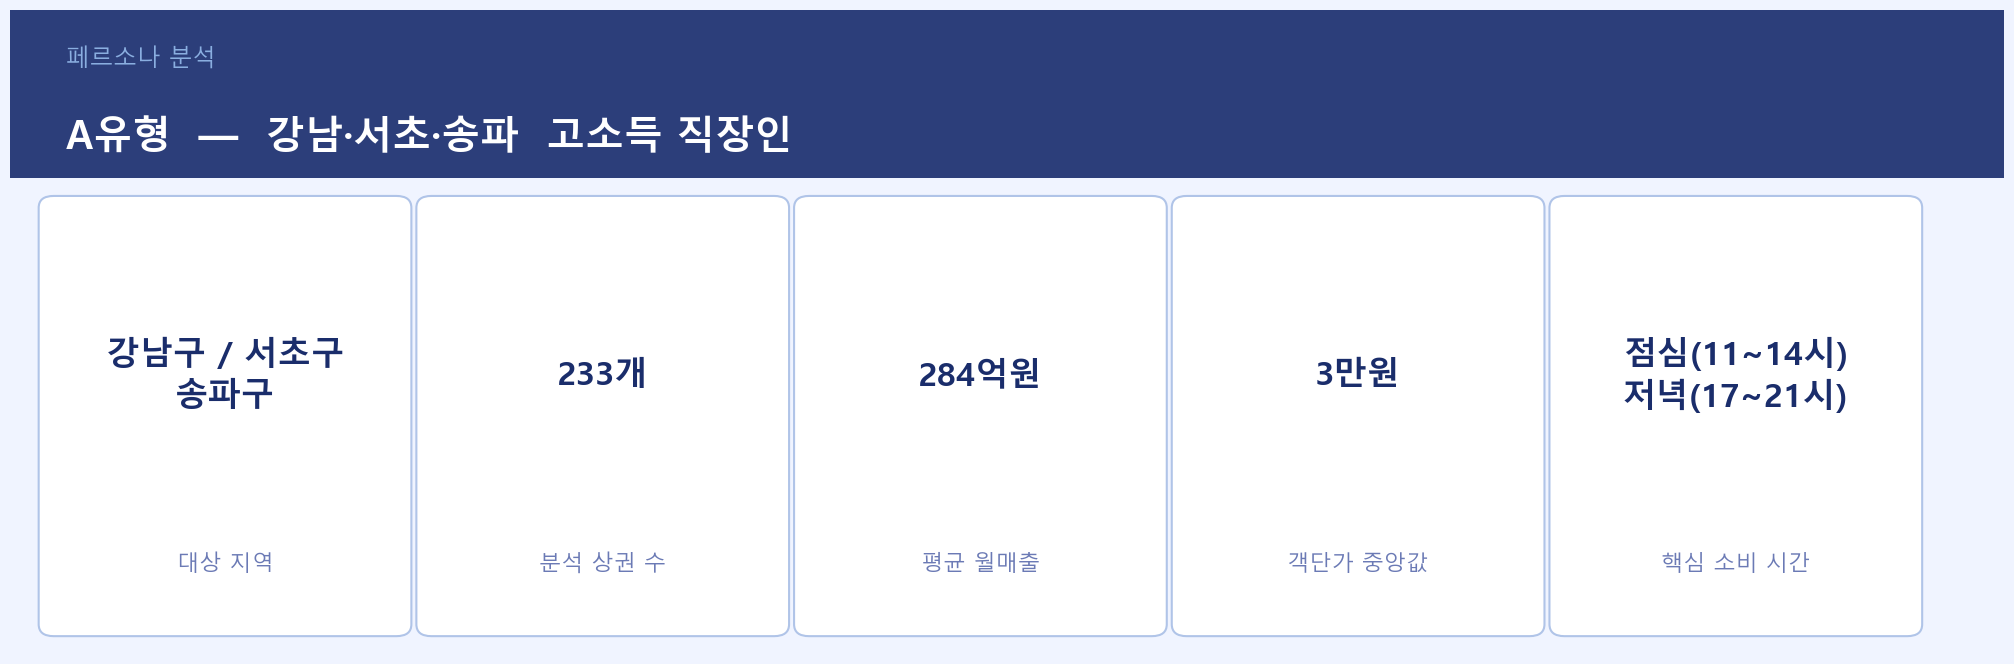

In [99]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# 기존 데이터 변수 할당 (그대로 사용)
avg_sales   = g['총매출_억'].mean()
median_unit = g['객단가'].median()

attrs = [
    ('대상 지역',    '강남구 / 서초구\n송파구'),
    ('분석 상권 수',  f'{len(g)}개'),
    ('평균 월매출',   f'{avg_sales:.0f}억원'),
    ('객단가 중앙값',  f'{median_unit/10000:.0f}만원'),
    ('핵심 소비 시간', '점심(11~14시)\n저녁(17~21시)'),
]

# 1. 캔버스(Figure) 크기 확대 (기존 16, 4.5 -> 20, 6.5)
fig = plt.figure(figsize=(20, 6.5))
ax  = fig.add_subplot(111)

# 2. Y축 좌표계 확장 (글자가 들어갈 세로 공간 확보 0~4.5 -> 0~6.5)
ax.set_xlim(0, 16)
ax.set_ylim(0, 6.5)
ax.axis('off')
fig.patch.set_facecolor('#f0f4ff')
ax.set_facecolor('#f0f4ff')

# ── Header strip (위치 및 세로 두께 확대)
ax.add_patch(FancyBboxPatch((0, 4.8), 16, 1.7, boxstyle='square,pad=0',
                             facecolor='#2c3e7a', edgecolor='none'))

# 소제목 폰트 확대 (9 -> 17)
ax.text(0.45, 6.0, '페르소나 분석', fontsize=17, color='#8aaee0', va='center', style='italic')
# 메인 제목 폰트 확대 (14 -> 28)
ax.text(0.45, 5.2, 'A유형  —  강남·서초·송파  고소득 직장인',
        fontsize=28, color='white', fontweight='bold', va='center')

# ── Attribute boxes (박스 높이 및 텍스트 위치 조정)
box_w, gap, start_x = 2.75, 0.28, 0.35
for i, (label, value) in enumerate(attrs):
    x = start_x + i * (box_w + gap)
    
    # 박스 세로 길이 확대 (2.8 -> 4.2)
    ax.add_patch(FancyBboxPatch((x, 0.3), box_w, 4.2,
                                 boxstyle='round,pad=0.12',
                                 facecolor='white', edgecolor='#b0c4e8', linewidth=1.5))
    
    # Value(값) 폰트 확대 (12 -> 24) 및 줄간격(linespacing) 조정
    ax.text(x + box_w / 2, 2.8, value,
            ha='center', va='center', fontsize=24, color='#1a2d6b',
            fontweight='bold', multialignment='center', linespacing=1.3)
    
    # Label(항목명) 폰트 확대 (8.5 -> 16)
    ax.text(x + box_w / 2, 0.9, label,
            ha='center', va='center', fontsize=16, color='#6b7ab5')

plt.tight_layout(pad=0.2)
# 파일명 겹침 방지를 위해 '_Large' 추가 권장
plt.savefig('../data/output/A유형_페르소나카드_Large.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 1. A유형 현황 — 강남·서초·송파 상권은 지금 어디에 있는가

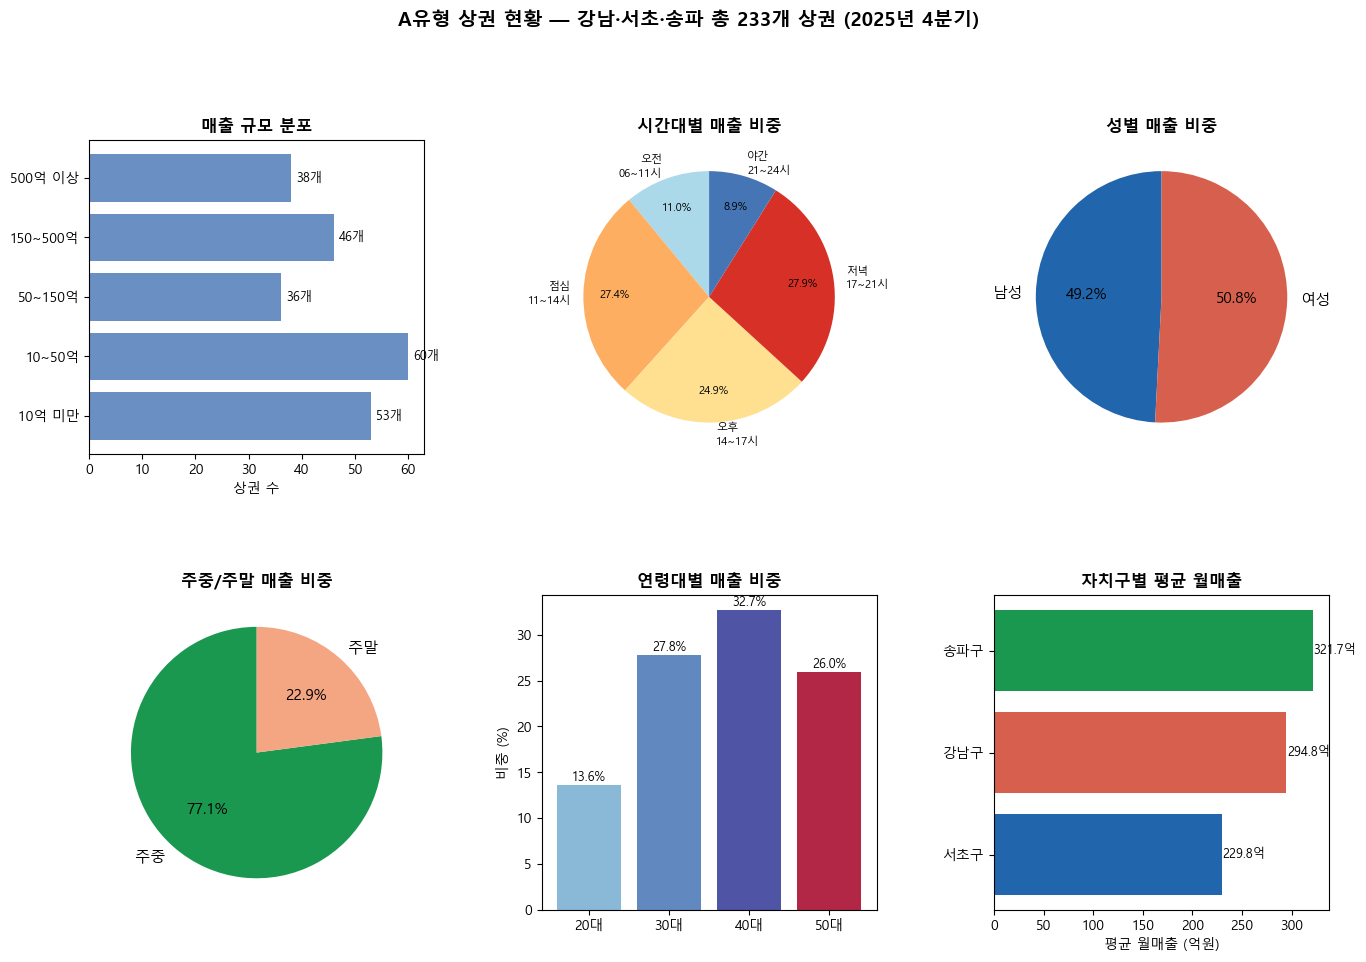

In [100]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (1) 매출 규모 분포
ax1 = fig.add_subplot(gs[0, 0])
bins = [0, 10, 50, 150, 500, g['총매출_억'].max() + 1]
labels_bin = ['10억 미만', '10~50억', '50~150억', '150~500억', '500억 이상']
g['매출구간'] = pd.cut(g['총매출_억'], bins=bins, labels=labels_bin)
매출구간_cnt = g['매출구간'].value_counts().reindex(labels_bin)
bars = ax1.barh(labels_bin, 매출구간_cnt.values, color='#4575b4', alpha=0.8)
for bar, val in zip(bars, 매출구간_cnt.values):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{val}개', va='center', fontsize=9)
ax1.set_xlabel('상권 수')
ax1.set_title('매출 규모 분포', fontweight='bold')

# ── (2) 시간대별 매출 비중 (전체 평균)
ax2 = fig.add_subplot(gs[0, 1])
time_cols = ['오전매출', '점심매출', '오후매출', '저녁매출', '야간매출']
time_labels = ['오전\n06~11시', '점심\n11~14시', '오후\n14~17시', '저녁\n17~21시', '야간\n21~24시']
time_vals = [g[c].sum() for c in time_cols]
time_pct = [v / sum(time_vals) * 100 for v in time_vals]
colors_t = ['#abd9e9', '#fdae61', '#fee090', '#d73027', '#4575b4']
wedges, texts, autotexts = ax2.pie(
    time_pct, labels=time_labels, autopct='%1.1f%%',
    colors=colors_t, startangle=90, pctdistance=0.75,
    textprops={'fontsize': 8}
)
for at in autotexts:
    at.set_fontsize(8)
ax2.set_title('시간대별 매출 비중', fontweight='bold')

# ── (3) 성별 매출 비중
ax3 = fig.add_subplot(gs[0, 2])
m_total = g['남성매출'].sum()
f_total = g['여성매출'].sum()
ax3.pie([m_total, f_total], labels=['남성', '여성'],
        autopct='%1.1f%%', colors=['#2166ac', '#d6604d'],
        startangle=90, textprops={'fontsize': 11})
ax3.set_title('성별 매출 비중', fontweight='bold')

# ── (4) 주중/주말 매출 비중
ax4 = fig.add_subplot(gs[1, 0])
wd = g['주중매출'].sum()
we = g['주말매출'].sum()
ax4.pie([wd, we], labels=['주중', '주말'],
        autopct='%1.1f%%', colors=['#1a9850', '#f4a582'],
        startangle=90, textprops={'fontsize': 11})
ax4.set_title('주중/주말 매출 비중', fontweight='bold')

# ── (5) 연령대별 매출 비중
ax5 = fig.add_subplot(gs[1, 1])
age_cols = ['연령20매출', '연령30매출', '연령40매출', '연령50매출']
age_labels = ['20대', '30대', '40대', '50대']
age_vals = [g[c].sum() for c in age_cols]
colors_a = ['#74add1', '#4575b4', '#313695', '#a50026']
ax5.bar(age_labels, [v/sum(age_vals)*100 for v in age_vals],
        color=colors_a, alpha=0.85)
for i, v in enumerate([v/sum(age_vals)*100 for v in age_vals]):
    ax5.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
ax5.set_ylabel('비중 (%)')
ax5.set_title('연령대별 매출 비중', fontweight='bold')

# ── (6) 자치구별 평균 월매출
ax6 = fig.add_subplot(gs[1, 2])
gu_매출 = g.groupby('자치구_코드_명')['총매출_억'].mean().sort_values(ascending=True)
ax6.barh(gu_매출.index, gu_매출.values, color=['#2166ac','#d6604d','#1a9850'])
for i, v in enumerate(gu_매출.values):
    ax6.text(v + 0.5, i, f'{v:.1f}억', va='center', fontsize=9)
ax6.set_xlabel('평균 월매출 (억원)')
ax6.set_title('자치구별 평균 월매출', fontweight='bold')

fig.suptitle(f'A유형 상권 현황 — 강남·서초·송파 총 {len(g)}개 상권 (2025년 4분기)',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('../data/output/A유형_현황.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. 상권 세분화 — 데이터가 말하는 4가지 유형

소비 패턴(시간대·성별·주말 비중)으로 K-Means 클러스터링을 수행한다.

In [101]:
FEAT_COLS = ['점심비중', '저녁비중', '야간비중', '주말비중', '여성비중']
g['log_객단가'] = np.log(g['객단가'])
FEAT_ALL = FEAT_COLS + ['log_객단가']

X_raw = g[FEAT_ALL].values
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# 최적 k 탐색
sil_scores = {}
for k in range(2, 7):
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    sil_scores[k] = silhouette_score(X, km_tmp.fit_predict(X))
best_k = max(sil_scores, key=sil_scores.get)
print(f'Silhouette scores: {sil_scores}')
print(f'최적 k = {best_k}')

# k=4 고정 (비즈니스 해석성 우선)
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
g['클러스터'] = km.fit_predict(X)

# ── 클러스터별 프로파일 (센트로이드 → 유형명 자동 결정)
profile = g.groupby('클러스터')[FEAT_COLS + ['총매출_억', '객단가']].mean()
print('\n클러스터별 평균 프로파일:')
print(profile.round(3))

# 유형명 자동 할당 (점심비중↑ → 오피스, 저녁+여성↑ → 프리미엄, 주말↑ → 복합, 나머지 → 일반)
def assign_name(row):
    if row['점심비중'] == profile['점심비중'].max():
        return '① 오피스 점심형'
    elif row['주말비중'] == profile['주말비중'].max():
        return '③ 주말 복합형'
    elif row['저녁비중'] + row['여성비중'] == (profile['저녁비중'] + profile['여성비중']).max():
        return '② 프리미엄 저녁형'
    else:
        return '④ 일반 근린형'

profile['유형명'] = profile.apply(assign_name, axis=1)

# 남은 클러스터 처리
used = set(profile['유형명'])
names_pool = ['① 오피스 점심형', '② 프리미엄 저녁형', '③ 주말 복합형', '④ 일반 근린형']
for idx in profile.index:
    if profile.loc[idx, '유형명'] not in names_pool:
        remaining = [n for n in names_pool if n not in used]
        profile.loc[idx, '유형명'] = remaining[0] if remaining else f'유형{idx}'
        used.add(profile.loc[idx, '유형명'])

# 중복 처리
seen = {}
for idx in profile.index:
    name = profile.loc[idx, '유형명']
    if name in seen:
        remaining = [n for n in names_pool if n not in set(profile['유형명'])]
        if remaining:
            profile.loc[idx, '유형명'] = remaining[0]
    seen[name] = idx

g['유형명'] = g['클러스터'].map(profile['유형명'])
print('\n유형별 상권 수:')
print(g['유형명'].value_counts())

Silhouette scores: {2: 0.17621796752645189, 3: 0.24222416585078232, 4: 0.19766033603307576, 5: 0.15284907742073794, 6: 0.18163703917108337}
최적 k = 3

클러스터별 평균 프로파일:
       점심비중   저녁비중   야간비중   주말비중   여성비중    총매출_억         객단가
클러스터                                                        
0     0.453  0.165  0.031  0.138  0.312  137.887   44509.418
1     0.277  0.283  0.075  0.241  0.426  339.509   27887.176
2     0.196  0.377  0.214  0.221  0.350   92.232   59363.266
3     0.248  0.271  0.047  0.204  0.504  395.879  150979.158

유형별 상권 수:
유형명
③ 주말 복합형      111
② 프리미엄 저녁형     51
① 오피스 점심형      38
④ 일반 근린형       33
Name: count, dtype: int64


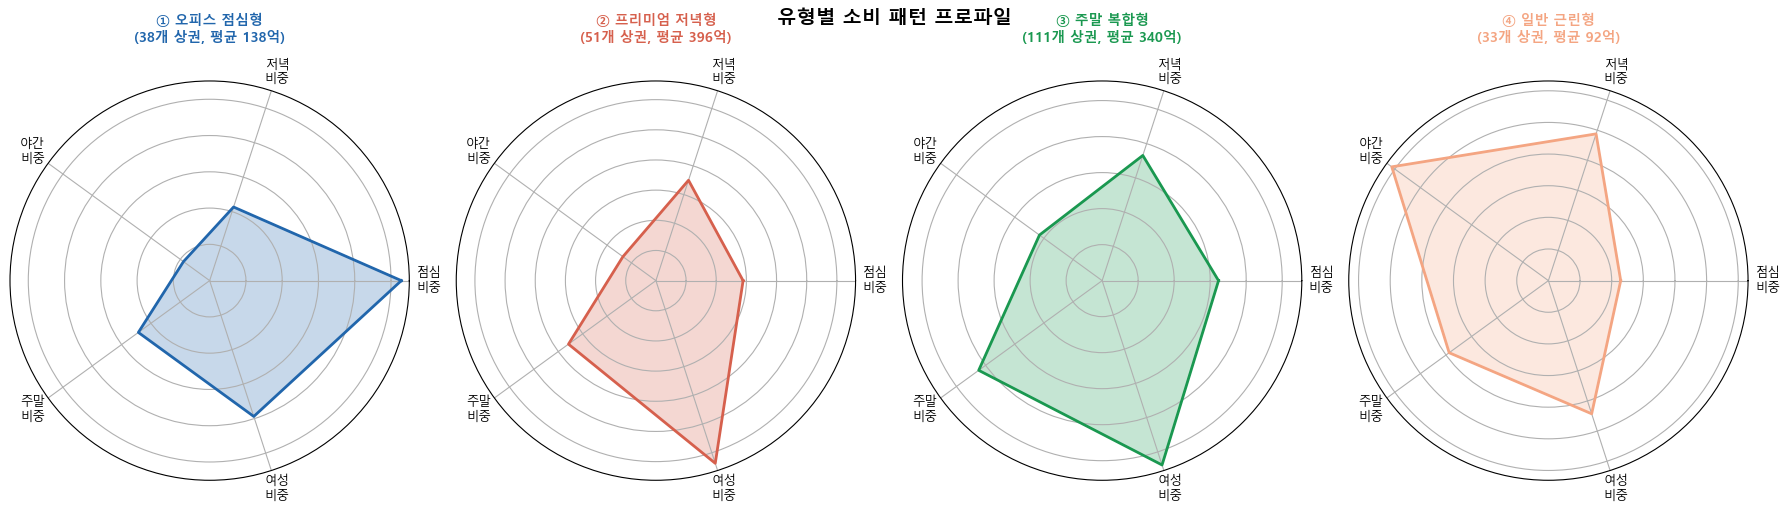

In [102]:
# ── 클러스터 프로파일 레이더 차트
from matplotlib.patches import FancyArrowPatch

유형_순서 = ['① 오피스 점심형', '② 프리미엄 저녁형', '③ 주말 복합형', '④ 일반 근린형']
color_map = {유형: OKR_COLORS[i] for i, 유형 in enumerate(유형_순서)}

radar_feats = ['점심비중', '저녁비중', '야간비중', '주말비중', '여성비중']
radar_labels = ['점심\n비중', '저녁\n비중', '야간\n비중', '주말\n비중', '여성\n비중']
N = len(radar_feats)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), subplot_kw=dict(polar=True))
fig.suptitle('유형별 소비 패턴 프로파일', fontsize=14, fontweight='bold')

유형_to_cluster = {v: k for k, v in profile['유형명'].items()}

for ax, 유형 in zip(axes, 유형_순서):
    cid = 유형_to_cluster.get(유형)
    if cid is None:
        continue
    subset = g[g['클러스터'] == cid]
    vals = [subset[f].mean() for f in radar_feats]
    # 0-1 정규화 (전체 기준)
    global_max = [g[f].max() for f in radar_feats]
    vals_norm = [v / m if m > 0 else 0 for v, m in zip(vals, global_max)]
    vals_norm += vals_norm[:1]

    ax.plot(angles, vals_norm, color=color_map[유형], linewidth=2)
    ax.fill(angles, vals_norm, alpha=0.25, color=color_map[유형])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_yticklabels([])
    ax.set_title(
        f'{유형}\n({len(subset)}개 상권, 평균 {subset["총매출_억"].mean():.0f}억)',
        fontsize=10, fontweight='bold', color=color_map[유형], pad=12
    )

plt.tight_layout()
plt.savefig('../data/output/A유형_클러스터_레이더.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. 유형별 문제 진단 + 맞춤 전략 + 예상 매출 지표

In [103]:
# ── 유형별 현재 → 목표 매출 계산
# 현재: 중앙값(median)  /  벤치마크: Q60  /  목표: 갭 15% + 연 최대 15% 성장 캡

strategy_info = {
    '① 오피스 점심형': {
        '문제': '점심 피크(11~14시) 외 매출 공백 큼. 주말은 사실상 휴면 상태.',
        '전략': [
            '1. AI 웨이팅/예약 시스템 도입 (캐치테이블 예약금 제도: 노쇼 1% 미만 및 운영 효율화 입증)',
            '2. 모바일 식권 B2B 연계 (식권대장 × 판교 상인회: 기업 식대 예산 유입으로 평일 고정 수요 확보)',
        ],
    },
    '② 프리미엄 저녁형': {
        '문제': '객단가는 높지만 방문 빈도가 낮아 총매출이 제한적. 주중 점심 비활성화.',
        '전략': [
            '1. 서울시 "로컬브랜드 상권" 집중 육성 (1기 상권 3년 성과: 외식업 매출 14~29% 누진적 증가 지표 확인)',
        ],
    },
    '③ 주말 복합형': {
        '문제': '주말 집중도가 높아 주중 5일간 매출이 취약. 야간 경제 활성화 필요.',
        '전략': [
            '1. 야간관광 특화 거리 및 차 없는 거리 조성 (대전 0시 축제 사례: 단일 행사 파급효과 1,739억원 증명)',
        ],
    },
    '④ 일반 근린형': {
        '문제': '매출/객단가가 모두 낮음. 상권 정체성 부재로 외부 방문 유인이 취약.',
        '전략': [
            '1. 반려동물 친화(Pet-friendly) 업종 전환 유도 (KB연구소: 반려가구 증가·외출/건강 관리 소비 트렌드 일치)',
            '2. 동네 상점 야간 무인 운영(스마트슈퍼) 도입 (중기부 시범사업: 야간 인건비 절감, 일 매출 최대 32.6% 증가)',
        ],
    },
}

results = {}
for 유형 in 유형_순서:
    cid = 유형_to_cluster.get(유형)
    if cid is None:
        continue
    subset = g[g['클러스터'] == cid]
    현재 = subset['총매출_억'].median()
    상권수 = len(subset)

    현실적_벤치마크 = subset['총매출_억'].quantile(0.60)
    갭 = max(현실적_벤치마크 - 현재, 0)
    임시_목표 = 현재 + 갭 * 0.15
    최종_목표 = min(임시_목표, 현재 * 1.15)
    개선율 = (최종_목표 - 현재) / 현재 * 100 if 현재 > 0 else 0
    연간효과_억 = (최종_목표 - 현재) * 6 * 상권수

    results[유형] = {
        '상권수': 상권수,
        '현재_억': 현재,
        '벤치마크_억': 현실적_벤치마크,
        '목표_억': 최종_목표,
        '개선율_%': 개선율,
        '연간효과_억': 연간효과_억,
    }
    info = strategy_info.get(유형, {})
    print(f'\n{"="*60}')
    print(f'  {유형}  ({상권수}개 상권)')
    print(f'{"="*60}')
    print(f'  [문제점] {info.get("문제", "-")}')
    print(f'\n  [맞춤 전략]')
    for s in info.get('전략', []):
        print(f'    {s}')
    print(f'\n  [예상 지표]')
    print(f'    현재 중앙값 월매출:    {현재:.1f}억원')
    print(f'    현실적 벤치마크(Q60): {현실적_벤치마크:.1f}억원')
    print(f'    1년 목표(상한선 적용): {최종_목표:.1f}억원  → +{개선율:.1f}% 향상')
    print(f'    유형 전체 연간 추가 매출: 약 {연간효과_억:.0f}억원')



  ① 오피스 점심형  (38개 상권)
  [문제점] 점심 피크(11~14시) 외 매출 공백 큼. 주말은 사실상 휴면 상태.

  [맞춤 전략]
    1. AI 웨이팅/예약 시스템 도입 (캐치테이블 예약금 제도: 노쇼 1% 미만 및 운영 효율화 입증)
    2. 모바일 식권 B2B 연계 (식권대장 × 판교 상인회: 기업 식대 예산 유입으로 평일 고정 수요 확보)

  [예상 지표]
    현재 중앙값 월매출:    26.5억원
    현실적 벤치마크(Q60): 44.8억원
    1년 목표(상한선 적용): 29.2억원  → +10.4% 향상
    유형 전체 연간 추가 매출: 약 628억원

  ② 프리미엄 저녁형  (51개 상권)
  [문제점] 객단가는 높지만 방문 빈도가 낮아 총매출이 제한적. 주중 점심 비활성화.

  [맞춤 전략]
    1. 서울시 "로컬브랜드 상권" 집중 육성 (1기 상권 3년 성과: 외식업 매출 14~29% 누진적 증가 지표 확인)

  [예상 지표]
    현재 중앙값 월매출:    43.9억원
    현실적 벤치마크(Q60): 158.4억원
    1년 목표(상한선 적용): 50.5억원  → +15.0% 향상
    유형 전체 연간 추가 매출: 약 2015억원

  ③ 주말 복합형  (111개 상권)
  [문제점] 주말 집중도가 높아 주중 5일간 매출이 취약. 야간 경제 활성화 필요.

  [맞춤 전략]
    1. 야간관광 특화 거리 및 차 없는 거리 조성 (대전 0시 축제 사례: 단일 행사 파급효과 1,739억원 증명)

  [예상 지표]
    현재 중앙값 월매출:    131.3억원
    현실적 벤치마크(Q60): 183.1억원
    1년 목표(상한선 적용): 139.1억원  → +5.9% 향상
    유형 전체 연간 추가 매출: 약 5177억원

  ④ 일반 근린형  (33개 상권)
  [문제점] 매출/객단가가 모두 낮음. 상권 정체성 부재로 외부 방문 유인이 취약.

  [맞춤 전략]
    1. 반려동물 친

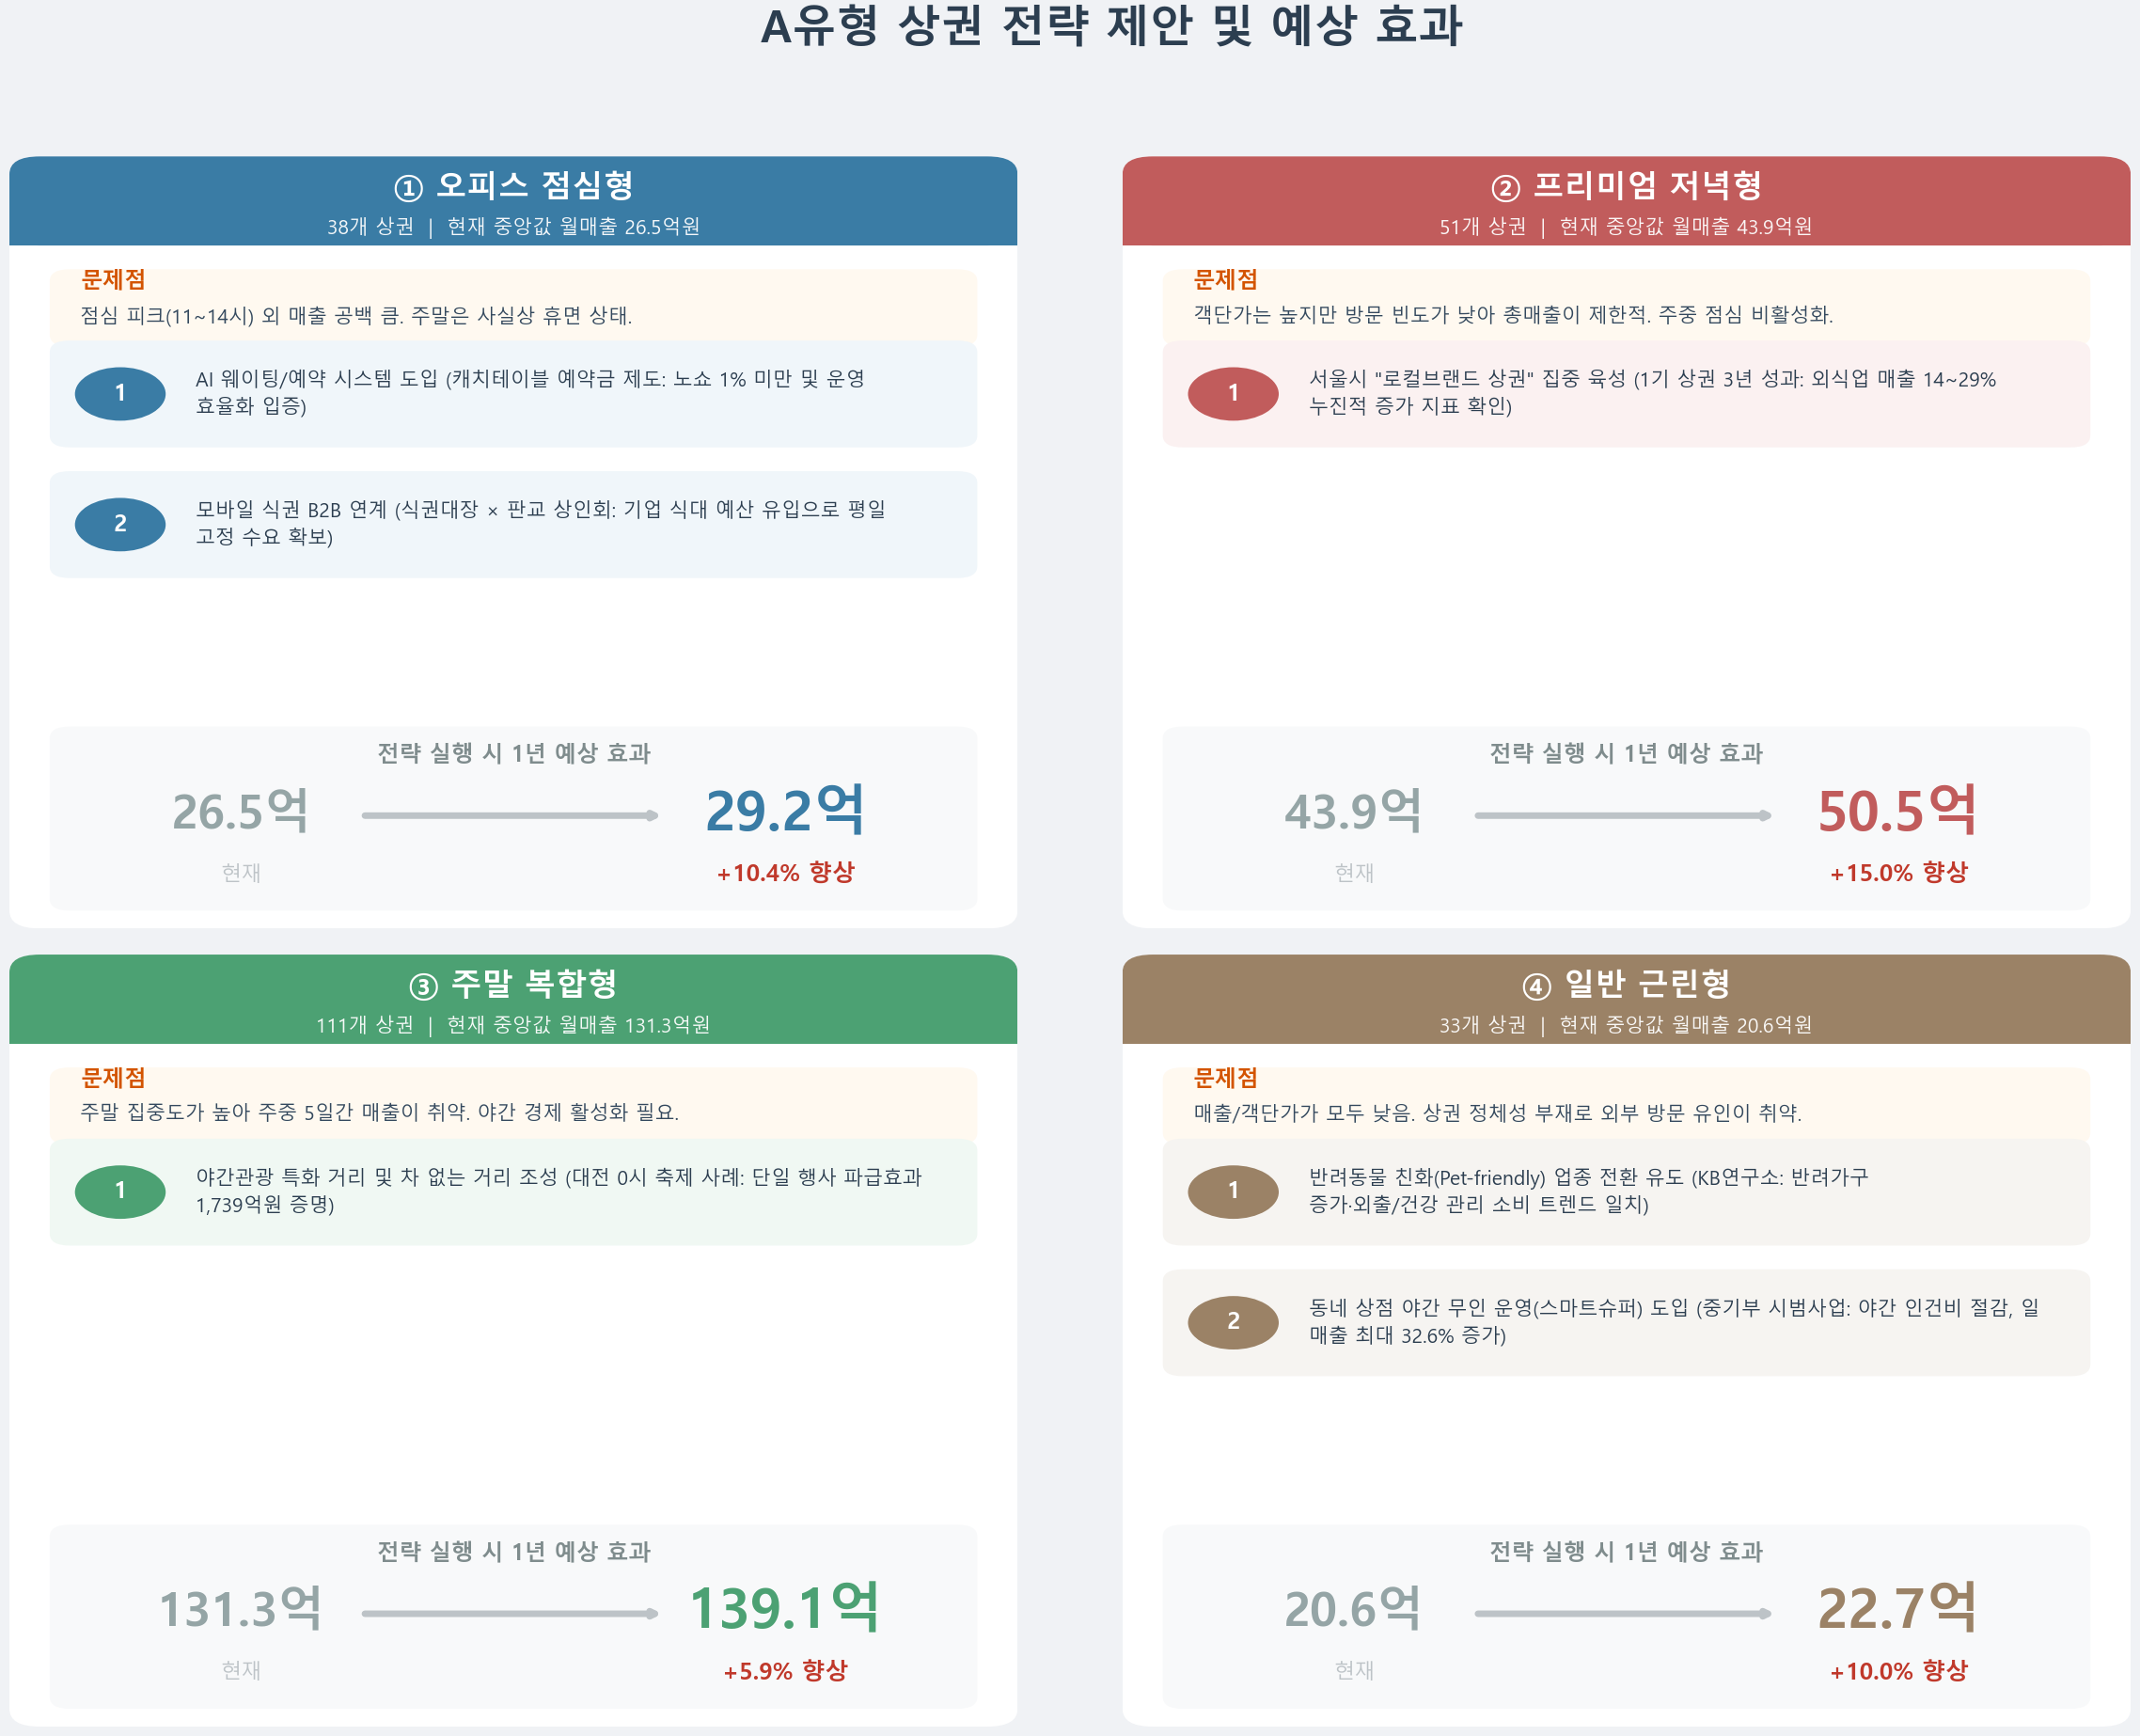

In [104]:
import textwrap, re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

유형_순서_v = ['① 오피스 점심형', '② 프리미엄 저녁형', '③ 주말 복합형', '④ 일반 근린형']
CARD_COLORS = {
    '① 오피스 점심형':  '#3A7CA5',
    '② 프리미엄 저녁형': '#C15C5C',
    '③ 주말 복합형':   '#4CA173',
    '④ 일반 근린형':   '#9B8266',
}
LIGHT_COLORS = {
    '① 오피스 점심형':  '#F0F6FA',
    '② 프리미엄 저녁형': '#FBF1F1',
    '③ 주말 복합형':   '#F0F8F3',
    '④ 일반 근린형':   '#F6F4F1',
}

fig, axes = plt.subplots(2, 2, figsize=(24, 18))
fig.patch.set_facecolor('#F0F2F5')
fig.suptitle('A유형 상권 전략 제안 및 예상 효과', fontsize=34, fontweight='bold', y=1.03, color='#2C3E50')

for ax, 유형 in zip(axes.flat, 유형_순서_v):
    color  = CARD_COLORS[유형]
    lcolor = LIGHT_COLORS[유형]
    r      = results.get(유형, {})
    info   = strategy_info.get(유형, {})

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 13)
    ax.axis('off')

    # 전체 배경 박스
    ax.add_patch(FancyBboxPatch((0, 0), 10, 13, boxstyle='round,pad=0,rounding_size=0.3',
                                 facecolor='white', edgecolor='none', zorder=0))

    # ── 헤더
    ax.add_patch(FancyBboxPatch((0, 11.5), 10, 1.5, boxstyle='round,pad=0,rounding_size=0.3',
                                 facecolor=color, edgecolor='none'))
    ax.add_patch(plt.Rectangle((0, 11.5), 10, 0.5, facecolor=color, edgecolor='none'))
    ax.text(5, 12.45, 유형, ha='center', va='center', fontsize=24, color='white', fontweight='bold')
    ax.text(5, 11.8,
            f'{r.get("상권수",0)}개 상권  |  현재 중앙값 월매출 {r.get("현재_억",0):.1f}억원',
            ha='center', va='center', fontsize=15, color='white', alpha=0.95)

    # ── 문제점
    ax.add_patch(FancyBboxPatch((0.4, 9.8), 9.2, 1.3, boxstyle='round,pad=0,rounding_size=0.2',
                                 facecolor='#FFF9F0', edgecolor='none'))
    ax.text(0.7, 10.8, '문제점', fontsize=17, color='#D35400', fontweight='bold')
    
    # 문제점 텍스트 넓게 (55자)
    prob_w = textwrap.fill(info.get('문제', ''), width=55)
    ax.text(0.7, 10.3, prob_w, fontsize=15, color='#34495E', va='center', linespacing=1.5)

    # ── 전략 박스 (상단 정렬 고정) ── #
    strats = info.get('전략', [])
    
    # 동적 로직을 과감히 없애고 기준 Y좌표를 3칸으로 고정
    strat_y_fixed = [8.1, 5.9, 3.7]

    # 존재하는 전략 개수(1~3개)만큼만 위에서부터 순서대로 그림
    for j, (s, top) in enumerate(zip(strats[:3], strat_y_fixed)):
        ax.add_patch(FancyBboxPatch((0.4, top), 9.2, 1.8, boxstyle='round,pad=0,rounding_size=0.2',
                                     facecolor=lcolor, edgecolor='none'))
        cy = top + 0.9
        
        ax.add_patch(mpatches.Circle((1.1, cy), 0.45, facecolor=color, edgecolor='none', zorder=3))
        ax.text(1.1, cy, str(j + 1), ha='center', va='center',
                fontsize=18, color='white', fontweight='bold', zorder=4)
        
        s_clean = re.sub(r'^\d+\.\s*', '', s)
        # 전략 텍스트 넓게 (48자)
        s_wrap  = textwrap.fill(s_clean, width=48)
        ax.text(1.85, cy, s_wrap, fontsize=15, color='#2C3E50', va='center', linespacing=1.45)

    # ── 예상 지표
    ax.add_patch(FancyBboxPatch((0.4, 0.3), 9.2, 3.1, boxstyle='round,pad=0,rounding_size=0.2',
                                 facecolor='#F8F9FA', edgecolor='none'))
    ax.text(5, 3.1, '전략 실행 시 1년 예상 효과',
            ha='center', va='top', fontsize=17, color='#7F8C8D', fontweight='bold')
    ax.text(2.3, 1.9, f'{r.get("현재_억",0):.1f}억',
            ha='center', va='center', fontsize=36, color='#95A5A6', fontweight='bold')
    ax.text(2.3, 0.9, '현재', ha='center', va='center', fontsize=16, color='#BDC3C7')
    
    ax.annotate('', xy=(6.5, 1.9), xytext=(3.5, 1.9),
                arrowprops=dict(arrowstyle='->', color='#BDC3C7', lw=5.0))
    
    ax.text(7.7, 1.9, f'{r.get("목표_억",0):.1f}억',
            ha='center', va='center', fontsize=42, color=color, fontweight='bold')
    ax.text(7.7, 0.9, f'+{r.get("개선율_%",0):.1f}% 향상',
            ha='center', va='center', fontsize=18, color='#C0392B', fontweight='bold')

plt.tight_layout(pad=2.0)
plt.savefig('../data/output/A유형_전략카드_TopAligned.png', dpi=300, bbox_inches='tight')
plt.show()

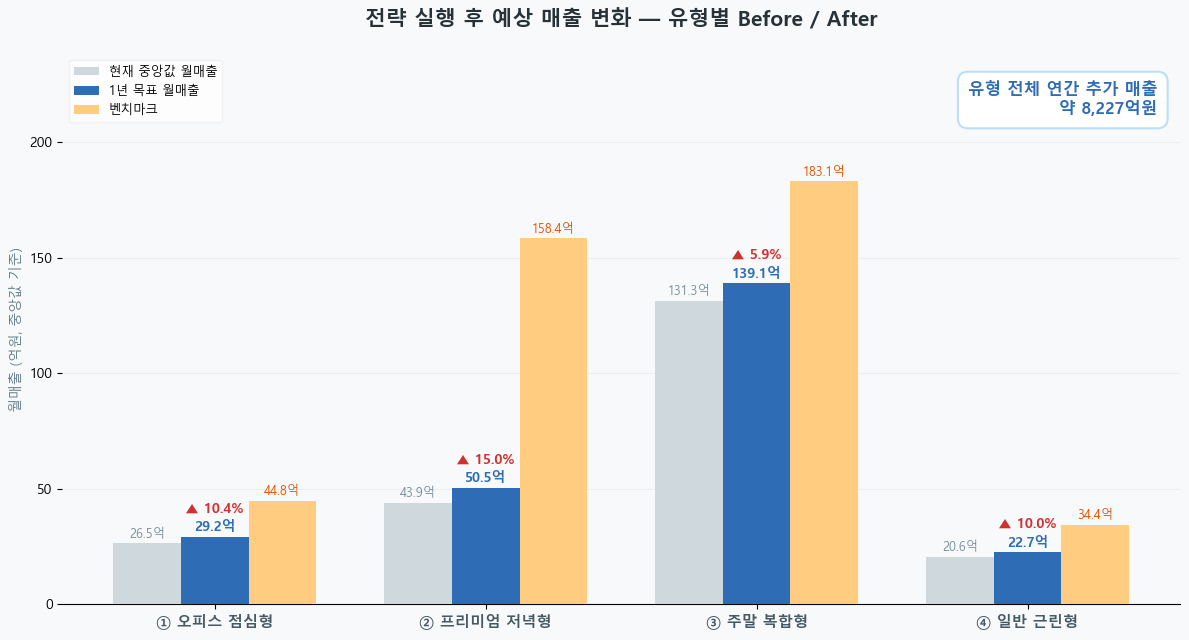

연간 추가 매출 유발 효과: 약 8,227억원


In [105]:
# ── Before / After 매출 비교 차트 (results는 앞 셀에서 계산됨)
유형_labels  = list(results.keys())
현재_vals    = [results[u]['현재_억']    for u in 유형_labels]
목표_vals    = [results[u]['목표_억']    for u in 유형_labels]
벤치마크_vals = [results[u]['벤치마크_억'] for u in 유형_labels]

fig, ax = plt.subplots(figsize=(12, 6.5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

x     = np.arange(len(유형_labels))
width = 0.25

bars_현재 = ax.bar(x - width, 현재_vals,    width, label='현재 중앙값 월매출', color='#CFD8DC', edgecolor='none', zorder=3)
bars_목표  = ax.bar(x,         목표_vals,    width, label='1년 목표 월매출',    color='#2E6CB5', edgecolor='none', zorder=3)
bars_bench = ax.bar(x + width, 벤치마크_vals, width, label='벤치마크',     color='#FFCC80', edgecolor='none', zorder=3)

for bar in bars_현재:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1, f'{h:.1f}억',
            ha='center', va='bottom', fontsize=9, color='#78909C')

for i, bar in enumerate(bars_목표):
    h = bar.get_height()
    개선율 = results[유형_labels[i]]['개선율_%']
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1, f'{h:.1f}억',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2E6CB5')
    ax.text(bar.get_x() + bar.get_width() / 2, h + max(벤치마크_vals) * 0.05,
            f'▲ {개선율:.1f}%', ha='center', va='bottom', fontsize=10,
            fontweight='bold', color='#D32F2F')

for bar in bars_bench:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1, f'{h:.1f}억',
            ha='center', va='bottom', fontsize=9, color='#E65100')

ax.set_xticks(x)
ax.set_xticklabels(유형_labels, fontsize=11, fontweight='bold', color='#455A64')
ax.set_ylabel('월매출 (억원, 중앙값 기준)', fontsize=10, color='#607D8B')
ax.set_title('전략 실행 후 예상 매출 변화 — 유형별 Before / After',
             fontsize=15, fontweight='bold', pad=20, color='#263238')
ax.grid(axis='y', linestyle='-', color='#ECEFF1', zorder=0)
sns.despine(left=True, bottom=False)
ax.legend(fontsize=9, loc='upper left', frameon=True, edgecolor='#EEEEEE', facecolor='white')
ax.set_ylim(0, max(벤치마크_vals) * 1.3)

total_연간 = sum(results[u]['연간효과_억'] for u in 유형_labels)
ax.text(0.98, 0.95,
        f'유형 전체 연간 추가 매출\n약 {total_연간:,.0f}억원',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=12, fontweight='bold', color='#2E6CB5',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='#BBDEFB', linewidth=1.5))

plt.tight_layout()
plt.savefig('../data/output/A유형_전략_BeforeAfter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'연간 추가 매출 유발 효과: 약 {total_연간:,.0f}억원')


---
## 4. 지도 시각화 — 유형별 상권 분포

In [106]:
# ── 유형별 색상 Folium 지도
유형_순서 = ['① 오피스 점심형', '② 프리미엄 저녁형', '③ 주말 복합형', '④ 일반 근린형']
color_map_folium = {
    '① 오피스 점심형':  '#2166ac',
    '② 프리미엄 저녁형': '#d6604d',
    '③ 주말 복합형':   '#1a9850',
    '④ 일반 근린형':   '#f4a582',
}

center_lat = g['lat'].mean()
center_lon = g['lon'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles='CartoDB positron'
)
MiniMap(toggle_display=True).add_to(m)

# 유형별 레이어 (토글 가능)
for 유형 in 유형_순서:
    subset = g[g['유형명'] == 유형].dropna(subset=['lat', 'lon'])
    color = color_map_folium.get(유형, '#888888')
    fg = folium.FeatureGroup(name=f'{유형} ({len(subset)}개)', show=True)

    for _, row in subset.iterrows():
        # 원 크기: 총매출 크기 비례 (min 4, max 18)
        radius = max(4, min(18, row['총매출_억'] ** 0.4))
        popup_html = (
            f"<b>{row['상권_코드_명']}</b><br>"
            f"유형: {유형}<br>"
            f"월매출: {row['총매출_억']:.1f}억원<br>"
            f"객단가: {row['객단가']:,.0f}원<br>"
            f"자치구: {row['자치구_코드_명']}"
        )
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.65,
            weight=1.2,
            popup=folium.Popup(popup_html, max_width=200),
            tooltip=row['상권_코드_명'],
        ).add_to(fg)
    fg.add_to(m)

# 범례 HTML
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:9999;
     background:#fff; padding:12px 16px; border-radius:8px;
     border:1px solid #ccc; font-size:13px; line-height:1.8;">
  <b>상권 유형</b><br>
  <span style="color:#2166ac;">&#9679;</span> ① 오피스 점심형<br>
  <span style="color:#d6604d;">&#9679;</span> ② 프리미엄 저녁형<br>
  <span style="color:#1a9850;">&#9679;</span> ③ 주말 복합형<br>
  <span style="color:#f4a582;">&#9679;</span> ④ 일반 근린형<br>
  <small style="color:#888;">원 크기 ∝ 월매출 규모</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False).add_to(m)

out_path = '../data/output/A유형_클러스터_지도.html'
m.save(out_path)
print(f'저장 완료: {out_path}')
m


저장 완료: ../data/output/A유형_클러스터_지도.html
